In [ ]:
try:
  import torchdiffeq
  import pytorch_lightning as pl
except:
  !pip install torchdiffeq
  !pip install pytorch_lightning
  import torchdiffeq
  import pytorch_lightning as pl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 973.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 945.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name    | Type          | Params
------------------------------------------
0 | odefunc | NeuralODEFunc | 451   
-----------------------

Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


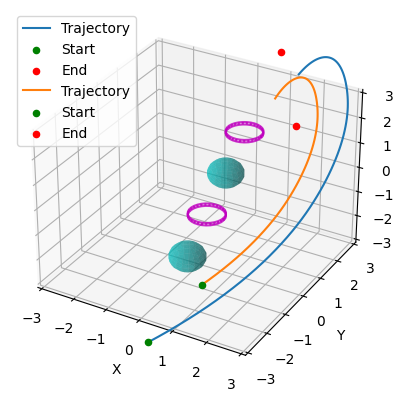

In [ ]:
# Modularizing the code for easy definition of an environment, and extending it for two starting and ending positions

import torch
import torch.nn as nn
from torchdiffeq import odeint
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


class NeuralODEFunc(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(NeuralODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, t, x):
        return self.net(x)


class Environment:
    def __init__(self, obstacle_centers, hoop_centers, obstacle_radius=0.5, hoop_radius=0.5):
        self.obstacle_centers = obstacle_centers
        self.hoop_centers = hoop_centers
        self.obstacle_radius = obstacle_radius
        self.hoop_radius = hoop_radius


class NeuralODE(pl.LightningModule):
    def __init__(self, env, start_positions, end_positions, input_dim=3, hidden_dim=64, output_dim=3):
        super(NeuralODE, self).__init__()
        self.odefunc = NeuralODEFunc(input_dim, hidden_dim, output_dim)
        self.start_positions = start_positions
        self.end_positions = end_positions
        self.env = env

    def forward(self, t, x):
        return odeint(self.odefunc, x, t)

    def train_dataloader(self):
        # Dummy dataset with one item
        dummy_data = torch.zeros(len(self.start_positions), 1).cuda()
        return DataLoader(TensorDataset(dummy_data), batch_size=len(self.start_positions))

    def loss_function(self, trajectory, end_position, obstacle_centers, hoop_centers):
      loss = ((trajectory[-1] - end_position) ** 2).sum()

      # Obstacle avoidance
      for center in obstacle_centers:
          sphere_sdf = torch.sqrt(((trajectory - center).pow(2)).sum(dim=-1)).sum()
          penalty = torch.sigmoid(sphere_sdf * 20)
          loss -= penalty

      # Hoop passing
      for center in hoop_centers:
          hoop_sdf = torch.abs(torch.sqrt(((trajectory - center).pow(2)).sum(dim=-1)).sum() - self.env.hoop_radius)
          penalty = torch.sigmoid(-hoop_sdf * 20)
          loss -= penalty

      return loss

    def training_step(self, batch, batch_idx):
        t = torch.linspace(0, 1, 10)
        loss = 0
        for start, end in zip(self.start_positions, self.end_positions):
            trajectory = self(t, start)
            loss += self.loss_function(trajectory, end, self.env.obstacle_centers, self.env.hoop_centers)
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-2)

    def plot_trajectory(self):
        device = next(self.parameters()).device  # Get the device of the model
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        t_test = torch.linspace(0, 1, 100)
        for start, end in zip(self.start_positions, self.end_positions):
            start, end = start.to(device), end.to(device)
            trajectory_test = self(t_test, start).detach().cpu()
            ax.plot(trajectory_test[:, 0, 0], trajectory_test[:, 0, 1], trajectory_test[:, 0, 2], label='Trajectory')
            ax.scatter(start[0, 0].cpu(), start[0, 1].cpu(), start[0, 2].cpu(), label='Start', color='g')
            ax.scatter(end[0, 0].cpu(), end[0, 1].cpu(), end[0, 2].cpu(), label='End', color='r')

        u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
        for center in self.env.obstacle_centers:
            x = center[0].cpu() + self.env.obstacle_radius * np.cos(u) * np.sin(v)
            y = center[1].cpu() + self.env.obstacle_radius * np.sin(u) * np.sin(v)
            z = center[2].cpu() + self.env.obstacle_radius * np.cos(v)
            ax.plot_surface(x, y, z, color='c', alpha=0.5)

        for center in self.env.hoop_centers:
            theta = np.linspace(0, 2.*np.pi, 30)
            z = np.linspace(-0.05, 0.05, 2)  # Thickness of the hoop
            theta, z = np.meshgrid(theta, z)

            x = center[0].cpu() + self.env.hoop_radius * np.cos(theta)
            y = center[1].cpu() + self.env.hoop_radius * np.sin(theta)
            z = center[2].cpu() + z

            ax.plot_wireframe(x, y, z, color='m', alpha=0.8)

        ax.set_xlabel('X')
        ax.set_xlim(-3,3)
        ax.set_ylim(-3,3)
        ax.set_zlim(-3,3)
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.legend()
        plt.show()


if __name__ == "__main__":
    start_positions = [torch.tensor([[0.5, -3.5, -3.5]], requires_grad=False).cuda(),
                       torch.tensor([[1.5, -2.5, -1.5]], requires_grad=False).cuda()]
    end_positions = [torch.tensor([[0.5, 3.5, 3.5]], requires_grad=False).cuda(),
                     torch.tensor([[1.5, 2.5, 1.5]], requires_grad=False).cuda()]
    obstacle_centers = [torch.tensor([0.5, 0.5, 0.5]).cuda(), torch.tensor([0.5, -1.5, -1.5]).cuda()]

    obstacle_centers = [torch.tensor([0.5, 0.5, 0.5]).cuda(), torch.tensor([0.5, -1.5, -1.5]).cuda()]
    hoop_centers = [torch.tensor([0.5, -0.5, -0.5]).cuda(), torch.tensor([0.5, 1.5, 1.5]).cuda()]
    env = Environment(obstacle_centers, hoop_centers)
    # env = Environment(obstacle_centers)

    model = NeuralODE(env, start_positions, end_positions)
    trainer = pl.Trainer(max_epochs=100, accelerator="auto")
    trainer.fit(model)

    model.plot_trajectory()


In [ ]:
trainer = pl.Trainer(max_epochs=100, accelerator="auto")
trainer.fit(model)

model.plot_trajectory()

NameError: ignored

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name    | Type          | Params
------------------------------------------
0 | odefunc | NeuralODEFunc | 451   
------------------------------------------
451       Trainable params
0         Non-trainable params
451       Total params
0.002     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


NameError: name 'cm' is not defined

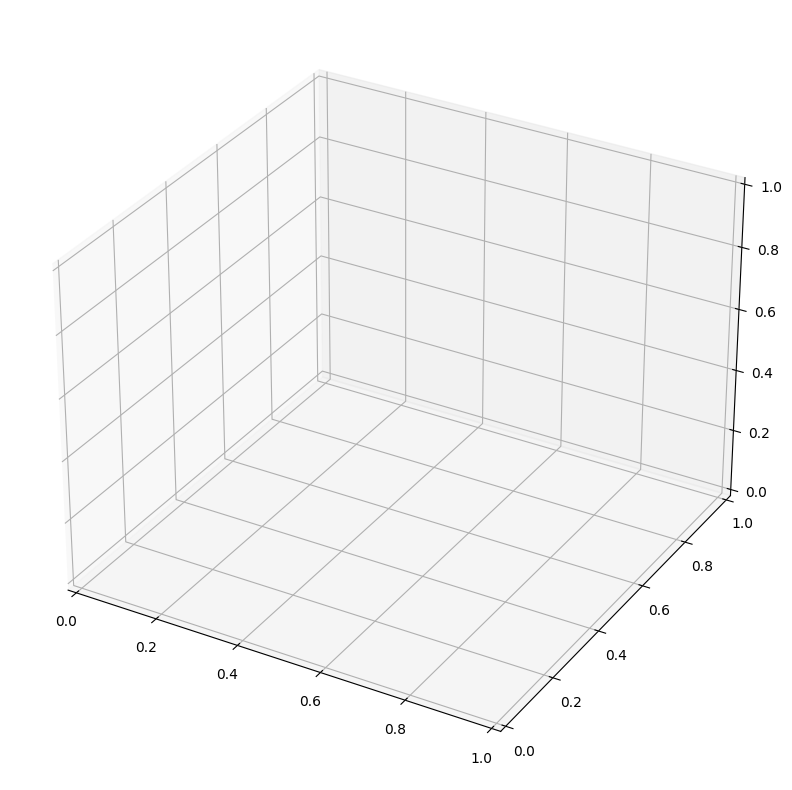

In [ ]:
import torch
import torch.nn as nn
from torchdiffeq import odeint
import pytorch_lightning as pl
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch.utils.data import DataLoader, TensorDataset


class NeuralODEFunc(nn.Module):
    def __init__(self):
        super(NeuralODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, t, x):
        return self.net(x)

class NeuralODE(pl.LightningModule):
    def __init__(self, start_position, end_positions, obstacle_centers, obstacle_radius=0.5):
        super(NeuralODE, self).__init__()
        self.odefunc = NeuralODEFunc()
        self.start_position = start_position
        self.end_positions = end_positions
        self.obstacle_centers = obstacle_centers
        self.obstacle_radius = obstacle_radius

    def forward(self, t, x):
        return odeint(self.odefunc, x, t)

    def train_dataloader(self):
        # Dummy dataset with one item
        dummy_data = torch.zeros(1).cuda()
        return DataLoader(TensorDataset(dummy_data), batch_size=1)

    def loss_function(self, trajectory, end_position, obstacle_centers):
        loss = ((trajectory[-1] - end_position) ** 2).sum()
        for center in obstacle_centers:
            sphere_sdf = torch.sqrt(((trajectory - center).pow(2)).sum(dim=-1)).sum()
            penalty = torch.sigmoid(sphere_sdf * 20)
            loss -= penalty
        return loss

    def training_step(self, batch, batch_idx):
        t = torch.linspace(0, 1, 10)
        loss = 0
        for end_position in self.end_positions:
            trajectory = self(t, self.start_position)
            loss += self.loss_function(trajectory, end_position, self.obstacle_centers)
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-2)

    def plot_trajectory(self, end_position):
        device = next(self.parameters()).device  # Get the device of the model
        self.start_position = self.start_position.to(device)
        end_position = end_position.to(device)

        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Custom color palette
        colors = ['#FF5733', '#1B6A9E']
        cmap = cm.get_cmap('cool')

        t_test = torch.linspace(0, 1, 100)
        trajectory_test = self(t_test, self.start_position).detach().cpu()

        ax.plot(trajectory_test[:, 0, 0], trajectory_test[:, 0, 1], trajectory_test[:, 0, 2],
                color=colors[0], label='Trajectory', linewidth=2)
        ax.scatter(self.start_position[0, 0].cpu(), self.start_position[0, 1].cpu(), self.start_position[0, 2].cpu(),
                  label='Start', color='g', s=100, marker='o')
        ax.scatter(end_position[0, 0].cpu(), end_position[0, 1].cpu(), end_position[0, 2].cpu(),
                  label='End', color='r', s=100, marker='*')

        u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
        for center in self.obstacle_centers:
            x = center[0].cpu() + self.obstacle_radius * np.cos(u) * np.sin(v)
            y = center[1].cpu() + self.obstacle_radius * np.sin(u) * np.sin(v)
            z = center[2].cpu() + self.obstacle_radius * np.cos(v)
            ax.plot_surface(x, y, z, color='c', alpha=0.5)

        # Colorbar to represent trajectory progress
        sm = cm.ScalarMappable(cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.1)
        cbar.set_label('Trajectory Progress', fontsize=12)

        ax.set_xlabel('X', fontsize=14)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_zlim(-3, 3)
        ax.set_ylabel('Y', fontsize=14)
        ax.set_zlabel('Z', fontsize=14)

        # Customize the legend
        legend = ax.legend(fontsize=12, loc='upper right', framealpha=0.8)
        legend.get_frame().set_facecolor('white')

        # Set background color
        ax.w_xaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))
        ax.w_yaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))
        ax.w_zaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))

        # Add grid
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

        # Set plot title
        ax.set_title('Trajectory Plot', fontsize=16)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    start_position = torch.tensor([[0.5, -3.5, -3.5]], requires_grad=False).cuda()
    end_positions = [torch.tensor([[0.5, 3.5, 3.5]], requires_grad=False).cuda()]
    obstacle_centers = [torch.tensor([0.5, 0.5, 0.5]).cuda(), torch.tensor([0.5, -1.5, -1.5]).cuda()]

    model = NeuralODE(start_position, end_positions, obstacle_centers)
    trainer = pl.Trainer(max_epochs=100, accelerator="auto")
    trainer.fit(model)

    for end_position in end_positions:
        model.plot_trajectory(end_position)


<ipython-input-3-348e380e243b>:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('cool')
<ipython-input-3-348e380e243b>:107: MatplotlibDeprecationWarning: The w_xaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use xaxis instead.
  ax.w_xaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))
<ipython-input-3-348e380e243b>:108: MatplotlibDeprecationWarning: The w_yaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use yaxis instead.
  ax.w_yaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))
<ipython-input-3-348e380e243b>:109: MatplotlibDeprecationWarning: The w_zaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use zaxis instead.
  ax.w_zaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))


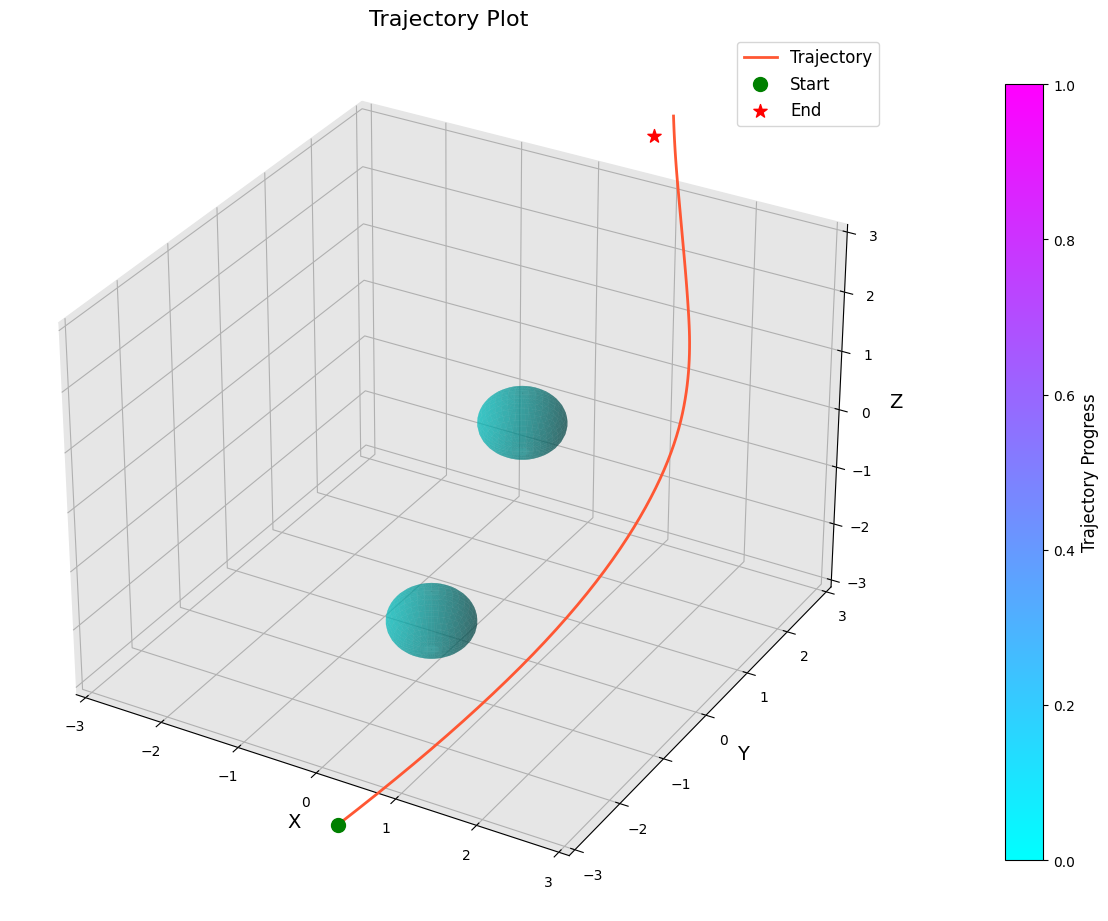

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np
import torch

for end_position in end_positions:
        model.plot_trajectory(end_position)

In [ ]:
import torch
import torch.nn as nn
from torchdiffeq import odeint
import pytorch_lightning as pl
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch.utils.data import DataLoader, TensorDataset


class NeuralODEFunc(nn.Module):
    def __init__(self):
        super(NeuralODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, t, x):
        return self.net(x)

class NeuralODE(pl.LightningModule):
    def __init__(self, start_position, end_positions, obstacle_centers, obstacle_radius=0.5):
        super(NeuralODE, self).__init__()
        self.odefunc = NeuralODEFunc()
        self.start_position = start_position
        self.end_positions = end_positions
        self.obstacle_centers = obstacle_centers
        self.obstacle_radius = obstacle_radius

    def forward(self, t, x):
        return odeint(self.odefunc, x, t)

    def train_dataloader(self):
        # Dummy dataset with one item
        dummy_data = torch.zeros(1).cuda()
        return DataLoader(TensorDataset(dummy_data), batch_size=1)

    def loss_function(self, trajectory, end_position, obstacle_centers, hoop_R=0.5, hoop_r=0.1, cylinder_centers=None, cylinder_h=1.0, cylinder_r=0.2):
        loss = ((trajectory[-1] - end_position) ** 2).sum()

        # Reward for passing through hoops
        for center in obstacle_centers:
            dist_to_center_xy = torch.sqrt(((trajectory[:, :, :2] - center[:2]).pow(2)).sum(dim=-1))
            hoop_condition = torch.abs(dist_to_center_xy - hoop_R)
            hoop_reward = torch.sigmoid((hoop_r - hoop_condition) * 20)
            loss -= hoop_reward.sum()

        # Penalty for hitting cylinders
        if cylinder_centers is not None:
            for center in cylinder_centers:
                dist_to_center_xy = torch.sqrt(((trajectory[:, :, :2] - center[:2]).pow(2)).sum(dim=-1))
                z_condition = (trajectory[:, :, 2] > center[2]) & (trajectory[:, :, 2] < (center[2] + cylinder_h))
                cylinder_penalty = torch.sigmoid((cylinder_r - dist_to_center_xy) * 20) * z_condition.float()
                loss += cylinder_penalty.sum()

        return loss

    def training_step(self, batch, batch_idx):
        t = torch.linspace(0, 1, 10)
        loss = 0
        for end_position in self.end_positions:
            trajectory = self(t, self.start_position)
            loss += self.loss_function(trajectory, end_position, self.obstacle_centers)
        self.log('train_loss', loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-2)


    def plot_trajectory(self, end_position):
        device = next(self.parameters()).device  # Get the device of the model
        self.start_position = self.start_position.to(device)
        end_position = end_position.to(device)

        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Custom color palette
        colors = ['#FF5733', '#1B6A9E']
        cmap = cm.get_cmap('cool')

        t_test = torch.linspace(0, 1, 100)
        trajectory_test = self(t_test, self.start_position).detach().cpu()

        ax.plot(trajectory_test[:, 0, 0], trajectory_test[:, 0, 1], trajectory_test[:, 0, 2],
                color=colors[0], label='Trajectory', linewidth=2)
        ax.scatter(self.start_position[0, 0].cpu(), self.start_position[0, 1].cpu(), self.start_position[0, 2].cpu(),
                  label='Start', color='g', s=100, marker='o')
        ax.scatter(end_position[0, 0].cpu(), end_position[0, 1].cpu(), end_position[0, 2].cpu(),
                  label='End', color='r', s=100, marker='*')

        u = np.linspace(0, 2 * np.pi, 50)
        v = np.linspace(0, 2 * np.pi, 50)
        u, v = np.meshgrid(u, v)

        for center in self.obstacle_centers:
            R = 0.5  # Distance from the center of the tube to the center of the torus
            r = 0.1  # Radius of the tube
            x = center[0].cpu() + (R + r * np.cos(v)) * np.cos(u)
            y = center[1].cpu() + (R + r * np.cos(v)) * np.sin(u)
            z = center[2].cpu() + r * np.sin(v)
            ax.plot_surface(x, y, z, color='c', alpha=0.5)

        # Colorbar to represent trajectory progress
        sm = cm.ScalarMappable(cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.1)
        cbar.set_label('Trajectory Progress', fontsize=12)

        ax.set_xlabel('X', fontsize=14)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_zlim(-3, 3)
        ax.set_ylabel('Y', fontsize=14)
        ax.set_zlabel('Z', fontsize=14)

        # Customize the legend
        legend = ax.legend(fontsize=12, loc='upper right', framealpha=0.8)
        legend.get_frame().set_facecolor('white')

        # Set background color
        ax.w_xaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))
        ax.w_yaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))
        ax.w_zaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))

        # Add grid
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

        # Set plot title
        ax.set_title('Trajectory Plot', fontsize=16)

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    start_position = torch.tensor([[0.5, -3.5, -3.5]], requires_grad=False).cuda()
    end_positions = [torch.tensor([[0.5, 3.5, 3.5]], requires_grad=False).cuda()]
    obstacle_centers = [torch.tensor([1, 0.5, 0.5]).cuda(), torch.tensor([-1, -1.5, -1.5]).cuda()]

    model = NeuralODE(start_position, end_positions, obstacle_centers)
    trainer = pl.Trainer(max_epochs=100, accelerator="auto")
    trainer.fit(model)

    # for end_position in end_positions:
    #     model.plot_trajectory(end_position)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name    | Type          | Params
------------------------------------------
0 | odefunc | NeuralODEFunc | 451   
------------------------------------------
451       Trainable params
0         Non-trainable params
451       Total params
0.002     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


<ipython-input-7-9a569068b82c>:83: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('cool')
<ipython-input-7-9a569068b82c>:125: MatplotlibDeprecationWarning: The w_xaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use xaxis instead.
  ax.w_xaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))
<ipython-input-7-9a569068b82c>:126: MatplotlibDeprecationWarning: The w_yaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use yaxis instead.
  ax.w_yaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))
<ipython-input-7-9a569068b82c>:127: MatplotlibDeprecationWarning: The w_zaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use zaxis instead.
  ax.w_zaxis.set_pane_color((0.9, 0.9, 0.9, 1.0))


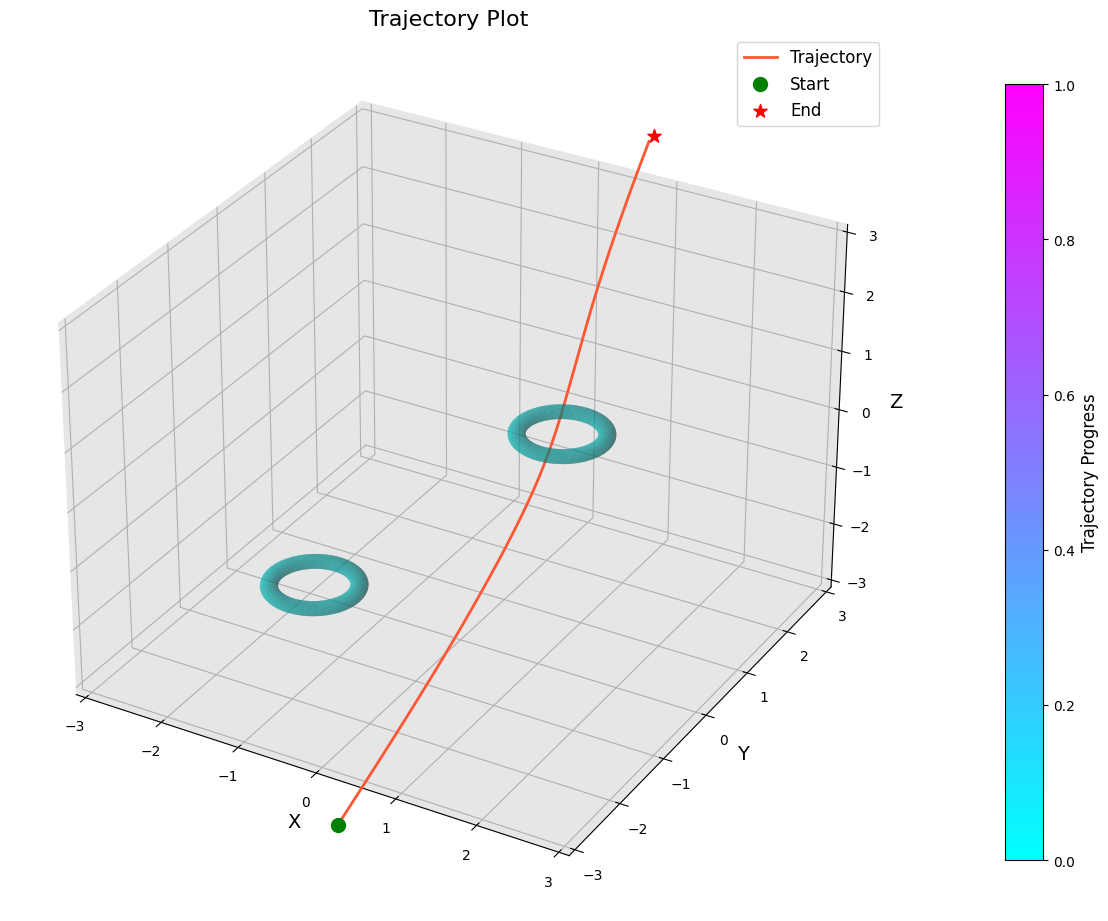

In [ ]:
for end_position in end_positions:
        model.plot_trajectory(end_position)

In [ ]:
import torch
import torch.nn as nn
from torchdiffeq import odeint
import matplotlib.pyplot as plt
import logging

# Initialize logging
logging.basicConfig(level=logging.INFO)

class NeuralODEFunc(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=2):
        super(NeuralODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, t, x):
        return self.net(x)

class NeuralODE(nn.Module):
    def __init__(self, atol=1e-3, rtol=1e-3):
        super(NeuralODE, self).__init__()
        self.atol = atol
        self.rtol = rtol
        self.odefunc = NeuralODEFunc()

    def forward(self, t, x):
        return odeint(self.odefunc, x, t, atol=self.atol, rtol=self.rtol)

def loss_function(trajectory, end_position):
    loss = ((trajectory[-1] - end_position) ** 2).sum()
    circle_sdf = torch.sqrt((trajectory.pow(2) - 0.5).sum(dim=-1)).sum()
    penalty = torch.sigmoid(circle_sdf * 20)
    return loss - penalty

def train_model(model, start_position, end_position, lr=1e-2, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lowest_loss = float('inf')
    best_model_state_dict = None
    best_epoch = 0

    for epoch in range(epochs):
        optimizer.zero_grad()
        t = torch.linspace(0, 1, 10)
        trajectory = model(t, start_position)
        loss = loss_function(trajectory, end_position)
        loss.backward()
        optimizer.step()

        if loss.item() < lowest_loss:
            lowest_loss = loss.item()
            best_epoch = epoch
            best_model_state_dict = model.state_dict().copy()

        if epoch % 10 == 0:
            logging.info(f'Epoch {epoch}, Loss: {loss.item()}')

    return best_model_state_dict, best_epoch

def plot_trajectory(model, start_position):
    t_test = torch.linspace(0, 1, 100)
    trajectory_test = model(t_test, start_position).detach()

    plt.plot(trajectory_test[:, 0, 0], trajectory_test[:, 0, 1], label='Trajectory')
    plt.scatter([start_position[0, 0]], [start_position[0, 1]], label='Start', color='g')
    plt.scatter([end_position[0, 0]], [end_position[0, 1]], label='End', color='r')
    circle = plt.Circle((0.5, 0.5), 0.5, color='r', fill=True, label='Obstacle')
    plt.gca().add_patch(circle)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.title('Neural ODE Trajectory')
    plt.grid(True)
    plt.axis('equal')
    plt.savefig('neural_ode_trajectory.png')

if __name__ == "__main__":
    model = NeuralODE()
    start_position = torch.tensor([[0.5, -3.5]], requires_grad=False)
    end_position = torch.tensor([[0.5, 3.5]], requires_grad=False)
    best_model_state_dict, best_epoch = train_model(model, start_position, end_position)

    model.load_state_dict(best_model_state_dict)
    torch.save(best_model_state_dict, f'best_model_{best_epoch}.pth')

    plot_trajectory(model, start_position)


ModuleNotFoundError: ignored

In [ ]:
import torch
import torch.nn as nn
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import logging

logging.basicConfig(level=logging.INFO)

class NeuralODEFunc(nn.Module):
    def __init__(self):
        super(NeuralODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 3)
        )

    def forward(self, t, x):
        return self.net(x)

class NeuralODE(nn.Module):
    def __init__(self):
        super(NeuralODE, self).__init__()
        self.odefunc = NeuralODEFunc()

    def forward(self, t, x):
        return odeint(self.odefunc, x, t)

def loss_function(trajectory, end_position):
    loss = ((trajectory[-1] - end_position) ** 2).sum()
    sphere_sdf = torch.sqrt((trajectory.pow(2) - 0.5).sum(dim=-1)).sum()
    penalty = torch.sigmoid(sphere_sdf * 20)
    return loss - penalty

def train_model(model, start_position, end_position, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
    lowest_loss = float('inf')
    best_model_state_dict = None
    best_epoch = 0

    for epoch in range(epochs):
        optimizer.zero_grad()
        t = torch.linspace(0, 1, 10)
        trajectory = model(t, start_position)
        loss = loss_function(trajectory, end_position)
        loss.backward()
        optimizer.step()

        if loss.item() < lowest_loss:
            lowest_loss = loss.item()
            best_epoch = epoch
            best_model_state_dict = model.state_dict().copy()

        if epoch % 10 == 0:
            logging.info(f'Epoch {epoch}, Loss: {loss.item()}')

    return best_model_state_dict, best_epoch

def plot_trajectory(model, start_position, end_position):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    t_test = torch.linspace(0, 1, 100)
    trajectory_test = model(t_test, start_position).detach()

    phi, theta = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = 0.5 + np.sin(theta) * np.cos(phi) * 0.5
    y = 0.5 + np.sin(theta) * np.sin(phi) * 0.5
    z = 0.5 + np.cos(theta) * 0.5
    ax.plot_surface(x, y, z, color='c', alpha=0.6)

    ax.plot(trajectory_test[:, 0, 0], trajectory_test[:, 0, 1], trajectory_test[:, 0, 2], label='Trajectory')
    ax.scatter(start_position[0, 0], start_position[0, 1], start_position[0, 2], label='Start', color='g')
    ax.scatter(end_position[0, 0], end_position[0, 1], end_position[0, 2], label='End', color='r')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

if __name__ == "__main__":
    model = NeuralODE()
    start_position = torch.tensor([[0.5, -3.5, -3.5]], requires_grad=False)
    end_position = torch.tensor([[0.5, 3.5, 3.5]], requires_grad=False)
    best_model_state_dict, best_epoch = train_model(model, start_position, end_position)

    model.load_state_dict(best_model_state_dict)
    torch.save(best_model_state_dict, f'best_model_3D_{best_epoch}.pth')

    plot_trajectory(model, start_position, end_position)


AssertionError: ignored

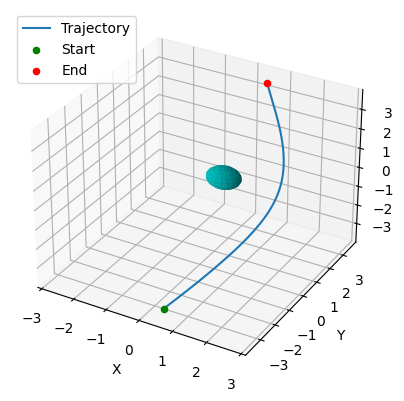

In [ ]:
import numpy as np

def plot_trajectory(model, start_position, end_position):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    t_test = torch.linspace(0, 1, 100)
    trajectory_test = model(t_test, start_position).detach()

    phi, theta = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = 0.5 + np.sin(theta) * np.cos(phi) * 0.5
    y = 0.5 + np.sin(theta) * np.sin(phi) * 0.5
    z = 0.5 + np.cos(theta) * 0.5
    ax.plot_surface(x, y, z, color='c', alpha=1)

    ax.plot(trajectory_test[:, 0, 0], trajectory_test[:, 0, 1], trajectory_test[:, 0, 2], label='Trajectory')
    ax.scatter(start_position[0, 0], start_position[0, 1], start_position[0, 2], label='Start', color='g')
    ax.scatter(end_position[0, 0], end_position[0, 1], end_position[0, 2], label='End', color='r')
    ax.set_xlim(-3,3)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    plt.show()

if __name__ == "__main__":
    model = NeuralODE()
    start_position = torch.tensor([[0.5, -3.5, -3.5]], requires_grad=False)
    end_position = torch.tensor([[0.5, 3.5, 3.5]], requires_grad=False)
    # best_model_state_dict, best_epoch = train_model(model, start_position, end_position)

    model.load_state_dict(best_model_state_dict)
    torch.save(best_model_state_dict, f'best_model_3D_{best_epoch}.pth')

    plot_trajectory(model, start_position, end_position)